In [1]:
from pydantic import BaseModel, Field
from typing_extensions import Literal, TypedDict
from pydantic import Field
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import END, StateGraph, START
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.document_loaders import WebBaseLoader
from typing import Annotated, List
import operator
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.types import Send
from IPython.display import Markdown, Image

from dotenv import load_dotenv

/var/folders/mp/s7vyjtmd5dj1l_2fflblh8zh0000gn/T/ipykernel_34740/1348738483.py:7: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import WebBaseLoader
USER_AGENT environment variable not set, consider setting it to identify your requests.


In [17]:
def extract_text(response) -> str:
    """ Normalizes an LLM response's content into a plain string.

    Some models (e.g. Gemini) can return `content` as a list of content
    blocks (dicts with a 'text' key, or plain strings) instead of a str.
    """
    if not response:
        return "No summary available."

    content = response.content
    if isinstance(content, list):
        text = "".join(
            part.get("text", "") if isinstance(part, dict) else str(part)
            for part in content
        )
    else:
        text = content

    return text.strip() if text else "No summary available."

In [18]:
# Schema for structured output to use in planning
class Section(BaseModel):
    name: str = Field(
        description="Name for this section of the report.",
    )
    description: str = Field(
        description="Brief overview of the main topics and concepts to be covered in this section.",
    )


class Sections(BaseModel):
    sections: List[Section] = Field(
        description="Sections of the report.",
    )

In [19]:
class SharedState(TypedDict):
    research_topic: str
    model: ChatGoogleGenerativeAI
    sections: list[Section]
    section_contents: Annotated[list[str], operator.add]
    final_report: str

In [20]:
def build_model(shared_state: SharedState) -> SharedState:
    shared_state['model'] = ChatGoogleGenerativeAI(model="gemini-3-flash-preview")
    return shared_state

In [21]:
def orchestrator(shared_state: SharedState) -> SharedState:
    model = shared_state['model']
    orchestrator_prompt = ChatPromptTemplate.from_template(
        "Create a detailed outline for a research report on the topic of {research_topic}. "
        "Break the report down into sections, each with a name and brief description. "
        "Limit the report to at max 5 sections."
    )

    model_with_structured_output = model.with_structured_output(Sections)
    retrieval_grader = orchestrator_prompt | model_with_structured_output
    result = retrieval_grader.invoke(
        {
            "research_topic": shared_state['research_topic'],
        }
    )
    shared_state['sections'] = [section for section in result.sections]

    return shared_state

In [22]:
def display_sections(sections: List[Section]) -> None:
    md_content = "## Report Sections\n"
    for idx, section in enumerate(sections, start=1):
        md_content += f"### Section {idx}: {section.name}\n{section.description}\n\n"
    display(Markdown(md_content))

In [23]:
load_dotenv()

shared_state = build_model({'research_topic': 'The impact of AI on modern education.'})
shared_state = orchestrator(shared_state)

display_sections(shared_state['sections'])

## Report Sections
### Section 1: Introduction to AI in the Educational Landscape
This section explores the evolution of artificial intelligence within academic settings, outlining the current technological shift and the scope of the report.

### Section 2: Enhancing Learning Outcomes through Personalization
An analysis of how AI-driven adaptive learning platforms and intelligent tutoring systems tailor educational content to individual student needs and improve engagement.

### Section 3: The Evolving Role of Educators and Institutional Efficiency
Examination of how AI automates administrative tasks and grading, allowing teachers to focus on mentorship while optimizing institutional resource management.

### Section 4: Ethical Considerations, Privacy, and Equity
A critical review of the risks associated with AI in education, including data privacy concerns, algorithmic bias, and the potential widening of the digital divide.

### Section 5: Future Projections and Strategic Recommendations
Synthesizing current trends to predict future developments in educational technology and providing actionable strategies for policy makers and institutions.



In [24]:
# Worker state
class WorkerState(TypedDict):
    section: Section
    model: ChatGoogleGenerativeAI
    completed_sections: Annotated[list, operator.add]

In [25]:
def worker(worker_state: WorkerState) -> SharedState:
    """Worker writes a section of the report"""
    print(f"\nWorker Spawned! Working on section: {worker_state['section'].name}")
    model = worker_state['model']
    section = worker_state['section']
    # Generate section
    response = model.invoke(
        [
            SystemMessage(
                content="Write a report section following the provided name and description. Include no preamble for each section. Use markdown formatting."
            ),
            HumanMessage(
                content=f"Here is the section name: {section.name} and description: {section.description}"
            ),
        ]
    )

    # Write the updated section to completed sections
    return {"section_contents": [extract_text(response)]}

In [26]:
# Conditional edge function to create llm_call workers that each write a section of the report
def spawn_workers(shared_state: SharedState):
    """Assign a worker to each section in the plan"""
    model = shared_state["model"]
    # Kick off section writing in parallel via Send() API
    return [
        Send("worker", {"section": section, "model": model}) 
        for section in shared_state["sections"]
    ]

In [27]:
def synthesizer(shared_state: SharedState):
    """Synthesize full report from sections"""

    # List of completed sections
    section_contents = shared_state["section_contents"]

    # Format completed section to str to use as context for final sections
    completed_report_sections = "\n\n---\n\n".join(section_contents)

    return {"final_report": completed_report_sections}

In [28]:
def build_workflow():
    # Build workflow
    orchestrator_worker_builder = StateGraph(SharedState)

    # Add the nodes
    orchestrator_worker_builder.add_node("build_model", build_model)
    orchestrator_worker_builder.add_node("orchestrator", orchestrator)
    orchestrator_worker_builder.add_node("worker", worker)
    orchestrator_worker_builder.add_node("synthesizer", synthesizer)

    # Add edges to connect nodes
    orchestrator_worker_builder.add_edge(START, "build_model")
    orchestrator_worker_builder.add_edge("build_model", "orchestrator")
    orchestrator_worker_builder.add_conditional_edges(
        "orchestrator", spawn_workers, ["worker"]
    )
    orchestrator_worker_builder.add_edge("worker", "synthesizer")
    orchestrator_worker_builder.add_edge("synthesizer", END)

    # Compile the workflow
    return orchestrator_worker_builder.compile()

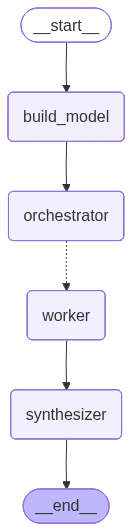

In [29]:
orchestrator_worker = build_workflow()

# Show the workflow
display(Image(orchestrator_worker.get_graph().draw_mermaid_png()))

In [31]:
state = orchestrator_worker.invoke({"research_topic": "How to prepare for a System Design technical Interview?"})

Markdown(state["final_report"])


Worker Spawned! Working on section: Foundational Principles of System Design
Worker Spawned! Working on section: The Step-by-Step Interview Framework


Worker Spawned! Working on section: Data Storage and Distribution Strategies

Worker Spawned! Working on section: Case Study Analysis and Practical Application

Worker Spawned! Working on section: Effective Communication and Performance Evaluation


ChatGoogleGenerativeAIError: Error calling model 'gemini-3-flash-preview' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-3-flash\nPlease retry in 7.150101562s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-Fr